# Lecture 6: Self-supervised learning and autoencoders


## Overview

In this project, I've trained various auto-encoders on the **MagnaTagATune** dataset to investigate how audio can be compressed, represented and reconstructed from a low-dimensional latent space. The primary goal was to **improve reconstruction quality**, treating it as a proxy for understanding how effectively the encoder captures salient audio structures. 

Throughout the notebook, I iteratively refined the baseline model by:
- Minimizing **sample-level MSE** and validating reconstruction quality 
- Applying **data augmentation** to amke the encoder more invariant and robust 
- Introducing **perceptual losses** using the STFT to enforce reconstruction fidelity beyond raw waveform similarity 

These experiments illustrate how architectural choices, augmentation pipelines, and loss functions influence an autoencoder’s ability to compress and reconstruct audio.


## Sections of the Notebook:
1. Load MagnaTagATune Dataset 
2. Proof of Concept - Train on a Single File 
3. Baseline Autoencoder Architetcture - Full dataset 
4. Augmentations to Baseline Model - Multi-Scale MSE & Data Augmentation
5. Perceptual Losses Added to Baseline 
6. Performance Evaluation of Models 

# 1. Load MagnaTagATune Dataset

As in previous projects (Lab 5 - Supervised Learning with CNN's), I re-used the same `MagnaTagATune` preprocessing class. This class: 
- Removes corrupt files
- Splits dataset into training, validation, and testing subsets
- Provides a `_crop_or_pad_` method that normalizes each sample to a fixed `target_duration` 

The cropping mechanism randomly selects a segment within longer audio files, while shorter files are padded with zeros. This standardization allows the autoecoders to: 

- Train efficiently on fixed-length tensors 
- Learn **generalizable features**, since since cropping prevents the model from memorizing large-scale structure
- Maintain consistent input dimensions, ensuring stable convolution and pooling operations throughout training. 


In [164]:
# Install deps

# !pip install torchcodec
# !pip install torch
# !pip install mirdata
# !pip install tqdm
# !pip install scikit-learn
# !pip install torchaudio
# !pip install matplotlib
# !pip install umap-learn

In [210]:

import numpy as np
import matplotlib.pyplot as plt
import mirdata
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import umap

# AP - newly added imports
import os
import torchaudio
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import warnings
import torchaudio.functional as ta_F
import torchaudio.transforms as T
import random

from sklearn.preprocessing import OneHotEncoder, MultiLabelBinarizer ## Added multilabelbinarizer
from torch.utils.data import DataLoader, Dataset
from torchaudio.transforms import MelSpectrogram, Resample
from tqdm import tqdm, trange

# AP - newly added imports
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    accuracy_score, 
    classification_report, 
    confusion_matrix 
)

# Set to cuda or cpu, depending on the runtime
#device = "cpu"
device = "mps"

In [166]:
# ==========================================================
# Load MagnaTagATune Annotations and Remove Corrupt Files
# ==========================================================

data_root = '../Lab 5'
mp3_root = '../Lab 5/mp3'

annotations = pd.read_csv(os.path.join(data_root, 'annotations_final.csv'), delimiter='\t')

# Identify empty MP3 files
empty_files = [
    file for file in annotations.mp3_path.values
    if file.lower().endswith('.mp3')
    and os.path.exists(os.path.join(mp3_root, file))
    and os.path.getsize(os.path.join(mp3_root, file)) == 0
]

print(f"Empty_files:\n{empty_files}")
print(len(annotations))

# Drop empty/corrupt files from the list of annotations
annotations = annotations[~annotations['mp3_path'].isin(empty_files)].reset_index(drop=True)

# Saving this version of annotations prior to genre filtering
all_annotations = annotations

print(len(annotations))

Empty_files:
['6/norine_braun-now_and_zen-08-gently-117-146.mp3', '8/jacob_heringman-josquin_des_prez_lute_settings-19-gintzler__pater_noster-204-233.mp3', '9/american_baroque-dances_and_suites_of_rameau_and_couperin-25-le_petit_rien_xiveme_ordre_couperin-88-117.mp3']
25863
25860


In [167]:
# ==========================================================
# Filter Annotations for Only Relevant Genre Info
# ==========================================================

song_info = pd.read_csv(os.path.join(data_root, 'song_info.csv'), on_bad_lines='skip').fillna('')

# Splitting and cleaning genre information
def split_genres(col):
    genres = [g.strip().lower() for i in song_info[col].values for g in i.split(',') if g.strip()]
    return list(set(genres))

mp3_genre = split_genres('mp3genre')
magnatunegenres = split_genres('magnatunegenres')

# Aggregate a "complete" list of genres from both columns into a final list of all genres
all_genres =list(set(mp3_genre + magnatunegenres))

# Match the column names in Annotations_File.csv with the list of genres we've compiled above
annotations_labels = annotations.columns.values
genre_columns = [i for i in annotations_labels if i in all_genres]

# List of columns we will want to pull from the annotations_file.csv file
selected_columns = ['clip_id'] + genre_columns + ['mp3_path']
annotations = annotations[selected_columns]

# Remove rows that do not have any genre labels
annotations = annotations[~(annotations[genre_columns].sum(axis=1) == 0)]

annotations['track_folder'] = [i[0] for i in annotations['mp3_path'].str.split('/')]

# Print the removed columns to visually confirm they are not genre related
kept_columns = selected_columns + ['track_folder']
removed_columns = [col for col in all_annotations if col not in kept_columns]
print(f"Total original columns: {len(all_annotations)}")
print(f"Columns kept: {len(kept_columns)}")
print(f"Columns removed: {len(removed_columns)}")
print(f"\nRemoved columns:\n{removed_columns}")

print("\nAnnotations Dataframe:")
annotations

Total original columns: 25860
Columns kept: 36
Columns removed: 155

Removed columns:
['no voice', 'singer', 'duet', 'plucking', 'bongos', 'female singing', 'clasical', 'sitar', 'chorus', 'female opera', 'male vocal', 'vocals', 'clarinet', 'heavy', 'silence', 'beats', 'men', 'woodwind', 'funky', 'no strings', 'chimes', 'foreign', 'no piano', 'horns', 'female', 'no voices', 'soft rock', 'eerie', 'spacey', 'quiet', 'no beat', 'banjo', 'electric', 'solo', 'violins', 'female voice', 'wind', 'happy', 'synth', 'no singing', 'middle eastern', 'trumpet', 'percussion', 'drum', 'airy', 'voice', 'repetitive', 'birds', 'space', 'strings', 'bass', 'harpsicord', 'male voice', 'girl', 'keyboard', 'acoustic', 'loud', 'classic', 'string', 'drums', 'electronic', 'not classical', 'chanting', 'no violin', 'not rock', 'no guitar', 'organ', 'no vocal', 'talking', 'weird', 'soprano', 'fast', 'acoustic guitar', 'electric guitar', 'male singer', 'man singing', 'classical guitar', 'violin', 'electro', 'tribal',

,clip_id,hard rock,world,harpsichord,classical,jazz,guitar,folk,ambient,new age,...,blues,vocal,indian,rock,techno,metal,hip hop,baroque,mp3_path,track_folder
0,2,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,f/american_bach_soloists-j_s__bach_solo_cantat...,f
1,6,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,f/american_bach_soloists-j_s__bach_solo_cantat...,f
2,10,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,f/american_bach_soloists-j_s__bach_solo_cantat...,f
3,11,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,f/american_bach_soloists-j_s__bach_solo_cantat...,f
4,12,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,f/american_bach_soloists-j_s__bach_solo_cantat...,f
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25855,58899,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,8/jacob_heringman-blame_not_my_lute-56-la_bres...,8
25856,58906,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,8/jacob_heringman-blame_not_my_lute-57-lost_is...,8
25857,58907,0,0,0,1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,8/jacob_heringman-blame_not_my_lute-57-lost_is...,8
25858,58908,0,0,0,1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,8/jacob_heringman-blame_not_my_lute-57-lost_is...,8


In [317]:
# ==========================================================
# Splitting Dataset Between Training / Validation / Testing
# ==========================================================

trainning_folders = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'a', 'b' ]
val_folders = ['c']
test_folders = ['d','e','f']

train_split = annotations[annotations['track_folder'].isin(trainning_folders)]
val_split = annotations[annotations['track_folder'].isin(val_folders)]
test_split = annotations[annotations['track_folder'].isin(test_folders)]

In [298]:

# convert the train_split dataframe into a numpy array and pull only genre related columns (i.e. the labels)
y_train = train_split[train_split.columns[1:-2]].values
y_val = val_split[val_split.columns[1:-2]].values
y_test = test_split[test_split.columns[1:-2]].values

# convert the train_split dataframe into a numpy array and pull only metadata to identify the song (i.e. 'clip_id' and 'mp3_path')
X_train = train_split[[train_split.columns[0],train_split.columns[-2]]].values
X_val = val_split[[val_split.columns[0],val_split.columns[-2]]].values
X_test = test_split[[test_split.columns[0],test_split.columns[-2]]].values

print('X_train Shape:', X_train.shape)
print("y_train Shape:", y_train.shape)


X_train Shape: (13033, 2)
y_train Shape: (13033, 33)


In [ ]:
# ================================
# Establishing Data Loading Class
# ================================

class MagnaTagATune(Dataset):
    def __init__(self, file_paths_and_ids, labels, target_duration=3.0, sample_rate=16000, transform=None, root_dir='./'):
        
        self.sample_rate = sample_rate # Standardized sample rate
        self.audio_duration = target_duration
        self.file_paths_and_ids = file_paths_and_ids # This contains the X_train/val/test ['clip_id', 'mp3_path'], ...]
        self.target_samples = max(int(target_duration * sample_rate), 1024)
        self.root_dir = root_dir
        self.transform = transform

        # Initialize MultiLabelBinarizer if not provided
        #if mlb is None:
        #    self.mlb = MultiLabelBinarizer()
        #    encoded_labels = self.mlb.fit_transform(labels)
        #else:
        #    self.mlb = mlb
        #    encoded_labels = self.mlb.transform(labels)

        #self.encoded_labels = encoded_labels  # <-- store encoded labels
        
        self.labels = {}
        self.audio_files = {}

        # Debug: basic info
        print(f"\nInitializing MagnaTagATune dataset with {len(file_paths_and_ids)} files.")
        print(f"Sample rate: {self.sample_rate}, Target samples: {self.target_samples}")

        # match labels with clip id for easier debugging
        for idx, (clip_id, relative_path) in enumerate(file_paths_and_ids):
            if not relative_path.startswith('mp3/'):
                relative_path = os.path.join('mp3', relative_path)
            self.audio_files[idx] = os.path.join(root_dir, relative_path)
            #self.labels[idx] = torch.tensor(encoded_labels[idx], dtype=torch.float32)  # <-- use encoded
            self.labels[idx] = torch.tensor(labels[idx], dtype=torch.float32)  # <-- use encoded

    def __len__(self):
        return len(self.file_paths_and_ids)

    def _crop_or_pad(self, waveform):
        num_samples = waveform.shape[-1]
        if num_samples > self.target_samples:
            # Random crop during training, center crop for evaluation (though this dataset uses it for both)
            start = random.randint(0, num_samples - self.target_samples)
            waveform = waveform[:, start:start + self.target_samples]
        elif num_samples < self.target_samples:
            # Pad with zeros at the end
            pad_amount = self.target_samples - num_samples
            waveform = torch.nn.functional.pad(waveform, (0, pad_amount))
        return waveform

    def __getitem__(self, idx):
    
        path = self.audio_files[idx]

        # Debug print
        # print(f"\nLoading file {idx}: {path}")

        try:
            #audio, sr = self.decoder(path)
            audio, sr = torchaudio.load(path)

        except Exception as e:
            print(f"Failed to load {path}: {e}")
            # Return zero audio + zero lables to avoid breaking DataLoader
            audio = torch.zeros((1, self.target_samples))
            sr = self.sample_rate

        if sr != self.sample_rate:
            # If the original audio has a different sample rate, resample it
            audio = torchaudio.functional.resample(audio, sr, self.sample_rate)

        audio = self._crop_or_pad(audio)

        label = self.labels[idx]

        # Debug: print shape info
        # print(f"Loaded waveform shape: {audio.shape}, Label shape: {label.shape}")

        return {"audio": audio, "labels": label}


### <i>Processing Notes:</i> 

A crucial part of constructing an autoencoder is tracking tensor shapes throughout the encoder and decoder. Convolutions, pooling layers, and flattening operations each modify tensor size in ways that affect the linear layers and unpooling steps later on.

To avoid dimensionality mismatches, I first explored and verified the shapes of preprocessed audio tensors. This helped reason through how each layer transforms the input and ensured consistency across the model.

In [ ]:
# ==================================================
# Understanding the evolution of the audio file size 
# ==================================================

# First load the audio using torchaudio.load function and print shape
ex_path = "../Lab 5/mp3/1/ambient_teknology-phoenix-01-ambient_teknology-0-29.mp3"
ex_audio, ex_sr = torchaudio.load(ex_path)

# This represents the shapes of tensors that are in the train_dataset 
print("Shape of Waveform Extracted", ex_audio.shape)
print("Sample Rate:", ex_sr)
print("Track duration:", ex_audio.shape[1]/ex_sr, "seconds")

print("Example of values:", ex_audio[0:20])
print("Max value:", torch.max(ex_audio))
print("Min value:", torch.min(ex_audio))

# Next we load train_dataset into DataLoader class which helps us create batches for training purposes
ex_loader = DataLoader(ex_audio, batch_size=128, shuffle=True, pin_memory=False)
ex_batch = next(iter(ex_loader))
print("\nLoaded Audio Shape:", ex_batch.shape)

# This proves the file stays the same shape when it's in train_loader


Shape of Waveform Extracted torch.Size([1, 465984])
Sample Rate: 16000
Track duration: 29.124 seconds
Example of values: tensor([[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  7.9782e-07,
         -8.2747e-07,  3.3646e-07]])
Max value: tensor(1.0846)
Min value: tensor(-1.0410)

Loaded Audio Shape: torch.Size([1, 465984])


In [ ]:
# ==================================
# Implement Loading Data Functions
# ==================================

batch_size = 128 
target_duration = 3.0
sample_rate = 16000

train_transforms=None
val_transforms=None

# Instantiate the dataset using the corrected class
train_dataset = MagnaTagATune(X_train, y_train, target_duration=target_duration, transform=train_transforms, root_dir='../Lab 5')
val_dataset = MagnaTagATune(X_val, y_val,target_duration=target_duration, transform=val_transforms,root_dir='../Lab 5')

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, pin_memory=False)

first_batch = next(iter(val_loader))




Initializing MagnaTagATune dataset with 13033 files.
Sample rate: 16000, Target samples: 48000

Initializing MagnaTagATune dataset with 1337 files.
Sample rate: 16000, Target samples: 48000


# 2. Proof of Concept - train on a single file

Before training on the full dataset, I implemented a **minimal autoencoder** to verify the end-to-end reconstruction pipeline.

This simple model serves as an educational demonstration of:

- The encoder -> bottleneck -> decoder flow
- How features compress into a latent representation 
- How the decoder attempts to reconstruct the original waveform 

As expected, the reconstructions in this section differ significantly from the original audio. Because the model only uses a single convolutional layer with no regularization or expressive decoding capacity, it lacks the representational depth needed for high-quality reconstruction.

Nonetheless, this proof-of-concept stage provides an essential sanity check before introducing more advanced components such as **multi-scale MSE, augmentations, and perceptual losses.**

In [365]:
class AutoencConv1D(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder filterbank. Using stride for downsampling, padding (kernel_size/2-1) to center filter at 0.
        self.enc_conv1 = nn.Conv1d(in_channels=1, out_channels=32, kernel_size=2048, stride=1024, padding=1023, bias=True)

        # Decoder filterbank
        self.dec_convt1 = nn.ConvTranspose1d(in_channels=32, out_channels=1, kernel_size=2048, stride=1024, padding=1023, bias=True)

    def encoder(self, x):
        x = self.enc_conv1(x)
        x = torch.tanh(x)
        return x

    def decoder(self, x):
        x = self.dec_convt1(x)
        return x

    def forward(self, x):
        z = self.encoder(x)

        x_reconstructed = self.decoder(z)
        return x_reconstructed

In [366]:
batch = next(iter(val_loader))
waveform = batch["audio"][0]

print(f"`{batch['labels'][0]}` sound with shape: {waveform.shape}")

`tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.])` sound with shape: torch.Size([1, 48000])


In [367]:
from IPython.display import Audio
samplerate = 16000
print("Original Audio File:")
Audio(waveform.cpu().numpy(), rate=samplerate)


Original Audio File:


In [368]:
model = AutoencConv1D().to(device)
waveform = waveform.to(device)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"AutoencConv1D parameters: {num_params}")

AutoencConv1D parameters: 131105


In [369]:
# Do a forward pass to measure output length
waveform_reconstructed = model(waveform)
len_output = waveform_reconstructed.shape[1]

# Trim target reference to this duration
waveform_target = waveform[:,:len_output]
waveform_target.shape

torch.Size([1, 47106])

In [370]:
waveform_reconstructed = model(waveform).detach().cpu()
print("Reconstructed Audio File:")
Audio(waveform_reconstructed.numpy(), rate=samplerate)

Reconstructed Audio File:


In [371]:
print("Input:", waveform.shape)
bottleneck = model.encoder(waveform)
print("Bottleneck:", bottleneck.shape)
output = model.decoder(bottleneck)
print("Output:", output.shape)

Input: torch.Size([1, 48000])
Bottleneck: torch.Size([32, 47])
Output: torch.Size([1, 47106])


In [372]:
# Try on another audio
waveform2 = waveform = batch["audio"][1]
print(f"`{batch['labels'][1]}` sound with shape: {waveform2.shape}")

`tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])` sound with shape: torch.Size([1, 48000])


In [373]:
print("Original Audio File:")
Audio(waveform2.cpu().numpy(), rate=samplerate)

Original Audio File:


In [374]:
waveform2 = waveform2.to(device)
waveform2_reconstructed = model(waveform2).detach()
print("Reconstructed Audio File:")
Audio(waveform2_reconstructed.cpu().numpy(), rate=samplerate)

Reconstructed Audio File:


# 3. Baseline Autoencoder Architetcture - Training on the Full Dataset 

### Key Enhancements 
----

The baseline autoencoder extends the proof-of-concept model into a deeper, more expressive architecture. This model includes:

- **Three convolutional layers** in both the encoder and decoder
- **Checkpointing**, allowing training progress to be saved and resumed
- **Early stopping** with a patience of 5 epochs, preventing overfitting

Use of `torch.no_grad()` during validation, ensuring the validation loop performs clean inference without tracking gradients

The bottleneck size of **64** produces roughly **750× compression**, meaning most of the original waveform information is compressed into a highly compact latent representation. Understanding how tensor shapes evolve through this pipeline was essential for debugging convolution, pooling, and flattening operations, and I used several shape-inspection cells to validate each transformation.

In [185]:
# ==============================================================
# Understanding How shape evolves in the AudioAutoencoder Class
# ==============================================================

input_length=16000
bottleneck_size=64
kernel_size=5
channels=8
channel_mult=2
downsample=4
assert kernel_size % 2 == 1 #"kernel_size should be odd for same padding"
padding = kernel_size // 2

ex_batch = next(iter(val_loader))
ex_x = ex_batch["audio"]  

enc_conv1 = nn.Conv1d(1, channels, kernel_size=kernel_size, padding=padding)
enc_norm1 = nn.BatchNorm1d(channels)
enc_act1 = nn.PReLU()
pool1 = nn.MaxPool1d(2, stride=downsample, return_indices=True)

x = enc_act1(enc_norm1(enc_conv1(ex_x)))
print(x.size())
x, idx1 = pool1(x)
print("After pool:", x.shape)
print("Indices shape:", idx1.shape)


torch.Size([128, 8, 48000])
After pool: torch.Size([128, 8, 12000])
Indices shape: torch.Size([128, 8, 12000])


In [186]:
# =============================================
# Define the AudioAutoencoder Class - Baseline 
# =============================================

import torch
import torch.nn as nn

class AudioAutoencoder(nn.Module):
    """A more capable audio autoencoder featuring batch-norm, PReLu activations,
    and sharedd indices for the downsampling and upsampling layers.
    """
    def __init__(
        self,
        input_length=16000,
        bottleneck_size=64,
        kernel_size=5,
        channels=8,
        channel_mult=2,
        downsample=4,
    ):
        super().__init__()
        assert kernel_size % 2 == 1, "kernel_size should be odd for same padding"

        padding = kernel_size // 2

        # ----- Encoder -----
        self.enc_conv1 = nn.Conv1d(1, channels, kernel_size=kernel_size, padding=padding)
        self.enc_norm1 = nn.BatchNorm1d(channels)
        self.enc_act1 = nn.PReLU()
        self.pool1 = nn.MaxPool1d(2, stride=downsample, return_indices=True)

        self.enc_conv2 = nn.Conv1d(channels, channels * channel_mult, kernel_size=kernel_size, padding=padding)
        self.enc_norm2 = nn.BatchNorm1d(channels * channel_mult)
        self.enc_act2 = nn.PReLU()
        self.pool2 = nn.MaxPool1d(2, stride=downsample, return_indices=True)

        self.enc_conv3 = nn.Conv1d(channels * channel_mult, channels * channel_mult ** 2, kernel_size=kernel_size, padding=padding)
        self.enc_norm3 = nn.BatchNorm1d(channels * channel_mult ** 2)
        self.enc_act3 = nn.PReLU()
        self.pool3 = nn.MaxPool1d(2, stride=downsample, return_indices=True)

        enc_out_len = input_length // downsample ** 3 * channels * channel_mult ** 2  # 3× pooling halves length thrice
        self.enc_fc = nn.Linear(enc_out_len, bottleneck_size)

        comp_rate =  input_length / bottleneck_size
        print(f"Compression rate: {comp_rate:.1f}X")

        # ----- Decoder -----
        self.dec_fc = nn.Linear(bottleneck_size, enc_out_len)

        self.unpool3 = nn.MaxUnpool1d(2, stride=downsample)
        self.dec_deconv3 = nn.Conv1d(channels * channel_mult ** 2, channels * channel_mult, kernel_size=kernel_size, padding=padding)
        self.dec_act3 = nn.PReLU()

        self.unpool2 = nn.MaxUnpool1d(2, stride=downsample)
        self.dec_deconv2 = nn.Conv1d(channels * channel_mult, channels, kernel_size=kernel_size, padding=padding)
        self.dec_act2 = nn.PReLU()

        self.unpool1 = nn.MaxUnpool1d(2, stride=downsample)
        self.dec_deconv1 = nn.Conv1d(channels, 1, kernel_size=kernel_size, padding=padding)
        self.dec_tanh = nn.Tanh()

    def encoder(self, x):
        sizes, indices = [], []

        x = self.enc_act1(self.enc_norm1(self.enc_conv1(x)))
        sizes.append(x.size())
        x, idx1 = self.pool1(x)
        indices.append(idx1)

        x = self.enc_act2(self.enc_norm2(self.enc_conv2(x)))
        sizes.append(x.size())
        x, idx2 = self.pool2(x)
        indices.append(idx2)

        x = self.enc_act3(self.enc_norm3(self.enc_conv3(x)))
        sizes.append(x.size())
        x, idx3 = self.pool3(x)
        indices.append(idx3)
        x = x.flatten(start_dim=1)

        x = self.enc_fc(x)
        return x, indices, sizes

    # ----- Decoder -----
    def decoder(self, z, indices, sizes):
        idx1, idx2, idx3 = indices
        size1, size2, size3 = sizes

        x = self.dec_fc(z)
        x = x.view(size3[0], size3[1], -1)

        x = self.unpool3(x, idx3, output_size=size3)
        x = self.dec_act3(self.dec_deconv3(x))

        x = self.unpool2(x, idx2, output_size=size2)
        x = self.dec_act2(self.dec_deconv2(x))

        x = self.unpool1(x, idx1, output_size=size1)
        x = self.dec_tanh(self.dec_deconv1(x))

        return x

    # ----- Forward -----
    def forward(self, x):
        z, indices, sizes = self.encoder(x)
        x_r = self.decoder(z, indices, sizes)
        return x_r, z

## <i>Training Notes</i>

I updated the dataset loader so the target length is dynamically determined from `target_duration × sample_rate`.

The validation loop was modified to use with `torch.no_grad()`, ensuring gradient history did not accumulate and interfere with training stability.

In [ ]:
# Set variables ahead of training for the early stop function and to save the values of the model in a checkpoint

best_val_loss = float("inf")
checkpoint_path = "best_autoencoder.pt"

In [ ]:
# =============================
# Train the Model 
# =============================

target_length = int(target_duration * sample_rate) # Changed this to be dynamic based on the sample rate and the target duration 
bottleneck_size = 64
downsample = 4
model = AudioAutoencoder(input_length=target_length, bottleneck_size=bottleneck_size, downsample=downsample)
model.to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 20
patience = 5

# Defining the progress bar to be displayed during training 
pbar = trange(num_epochs, desc="Training", unit="epoch")

for epoch in pbar:

    # ----------------------
    # Training
    # ----------------------
    model.train()

    loss_train = []
    for i, batch in enumerate(train_loader):
        x = batch["audio"]          
        
        # Added to ensure shape is as expected
        x = x[:, :, :target_length]      
        x = x.to(device)
        
        optimizer.zero_grad()
        x_reconstr, _ = model(x)
        loss = criterion(x, x_reconstr)
        loss.backward()
        optimizer.step()
        loss_train.append(loss.item())

    loss_train = np.mean(loss_train)

    # ----------------------
    # Validation
    # ----------------------
    model.eval()

    loss_val = []
    with torch.no_grad(): ## added to avoid vanishing gradient in validation 
        for i, batch in enumerate(val_loader):
            x = batch["audio"]         
            
            # Added to ensure shape is as expected
            x = x[:, :, :target_length]
            x = x.to(device)

            x_reconstr, _ = model(x)
            loss = criterion(x, x_reconstr)
            loss_val.append(loss.item())

    loss_val = np.mean(loss_val)
    
    # ----------------------------
    # Early Stopping + Checkpoint
    # ----------------------------
    if loss_val < best_val_loss:
        best_val_loss = loss_val
        patience_counter = 0  # reset counter

        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_loss": loss_val,
            "train_loss": loss_train,
        }, checkpoint_path)

        print(f"\n New best model saved (val_loss={loss_val:.5f})\n")

    else:
        patience_counter += 1
        print(f"\nNo improvement. Patience: {patience_counter}/{patience}\n")

        if patience_counter >= patience:
            print("\n Early stopping triggered - training halted.\n")
            break

    pbar.set_postfix({"epoch": epoch+1, "train loss": f"{loss_train:.5f}", "val loss": f"{loss_val:.5f}"})

Compression rate: 750.0X


Training:   5%|▌         | 1/20 [01:49<34:41, 109.55s/epoch, epoch=1, train loss=0.02376, val loss=0.01565]


 New best model saved (val_loss=0.01565)



Training:  10%|█         | 2/20 [03:23<30:02, 100.13s/epoch, epoch=2, train loss=0.01192, val loss=0.01153]


 New best model saved (val_loss=0.01153)



...


 New best model saved (val_loss=0.00638)



Training:  95%|█████████▌| 19/20 [30:53<01:38, 98.49s/epoch, epoch=19, train loss=0.00599, val loss=0.00618]


 New best model saved (val_loss=0.00618)



Training: 100%|██████████| 20/20 [32:31<00:00, 97.56s/epoch, epoch=20, train loss=0.00594, val loss=0.00631]


No improvement. Patience: 1/5



In [ ]:
# =============================
# To Load A Saved Model Later 
# =============================

# checkpoint = torch.load("best_autoencoder.pt", map_location=device)
# model.load_state_dict(checkpoint["model_state_dict"])
# optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
# start_epoch = checkpoint["epoch"] + 1


In [ ]:
batch = next(iter(val_loader))
x = batch["audio"] 
x = x[:, :, :target_length]
x = x.to(device)
x_r, _ = model(x)
x_r = x_r.detach().cpu()

## Original audio:

In [203]:
Audio(x[4].squeeze().cpu().numpy(), rate=16000)

## Reconstructed audio:

In [204]:
Audio(x_r[4].squeeze().cpu().numpy(), rate=16000)

## Thoughts on the Reconstruction - Baseline Model

The reconstructed waveform contains substantial broadband noise. This is expected due to:

- The **very large compression factor (≈750×)**
- The limited representational capacity of a small latent space
- Convolutional downsampling discarding local details that were deemed less relevant for minimizing MSE

While coarse temporal structure is often preserved, finer spectral details are lost, resulting in an audible difference between the original and reconstructed audio.


# 4. Augmentations to Baseline Model - multi-scale MSE Loss / data augmentation

### Model Enhancements 
----
To improve reconstruction quality beyond what MSE alone could achieve, I introduced several architectural and training modifications:

#### 1. Skip Connections (U-Net Style)

Encoder feature maps are forwarded directly into the decoder via concatenation at matching spatial scales.
This provides the decoder with **high-resolution feature information** that would otherwise be lost through pooling.

#### 2. Data Augmentation Pipeline

To increase dataset variability and encourage more robust representations, I implemented:

- `add_noise()` — random Gaussian noise
- `random_gain()` — random amplitude scaling
- `random_shift()` — circular temporal shifts

This forces the encoder to learn **invariant and stable features** rather than memorizing local waveform structure.

#### 3. Multi-Scale MSE Loss

I introduced an additional loss term via average pooling at multiple scales.
This encourages the network to minimize reconstruction error at **both fine and coarse temporal resolutions**, improving overall stability.

These enhancements collectively produced lower absolute validation MSE compared to the baseline model, suggesting improved reconstruction fidelity.


In [222]:
# =============================================
# Define the AudioAutoencoder Class - Augmented 
# =============================================

class AudioAutoencoder_Aug(nn.Module):
    """Audio autoencoder with skip connections, batch-norm, PReLu activations,
    and shared indices for downsampling/upsampling. Includes audio resampling to 16kHz.
    """
    def __init__(
        self,
        input_length=16000,
        bottleneck_size=64,
        kernel_size=5,
        channels=8,
        channel_mult=2,
        downsample=4,
        original_sample_rate=None,  # Set to None if no resampling needed
        target_sample_rate=16000,
    ):
        super().__init__()
        assert kernel_size % 2 == 1, "kernel_size should be odd for same padding"

        padding = kernel_size // 2
        
        # Resampler (optional)
        if original_sample_rate is not None and original_sample_rate != target_sample_rate:
            self.resample = T.Resample(orig_freq=original_sample_rate, new_freq=target_sample_rate)
            self.use_resample = True
        else:
            self.resample = None
            self.use_resample = False
        
        self.target_sample_rate = target_sample_rate

        # ----- Encoder -----
        self.enc_conv1 = nn.Conv1d(1, channels, kernel_size=kernel_size, padding=padding)
        self.enc_norm1 = nn.BatchNorm1d(channels)
        self.enc_act1 = nn.PReLU()
        self.pool1 = nn.MaxPool1d(2, stride=downsample, return_indices=True)

        self.enc_conv2 = nn.Conv1d(channels, channels * channel_mult, kernel_size=kernel_size, padding=padding)
        self.enc_norm2 = nn.BatchNorm1d(channels * channel_mult)
        self.enc_act2 = nn.PReLU()
        self.pool2 = nn.MaxPool1d(2, stride=downsample, return_indices=True)

        self.enc_conv3 = nn.Conv1d(channels * channel_mult, channels * channel_mult ** 2, kernel_size=kernel_size, padding=padding)
        self.enc_norm3 = nn.BatchNorm1d(channels * channel_mult ** 2)
        self.enc_act3 = nn.PReLU()
        self.pool3 = nn.MaxPool1d(2, stride=downsample, return_indices=True)

        enc_out_len = input_length // downsample ** 3 * channels * channel_mult ** 2
        self.enc_fc = nn.Linear(enc_out_len, bottleneck_size)

        comp_rate = input_length / bottleneck_size
        print(f"Compression rate: {comp_rate:.1f}X")

        # ----- Decoder -----
        self.dec_fc = nn.Linear(bottleneck_size, enc_out_len)

        self.unpool3 = nn.MaxUnpool1d(2, stride=downsample)
        self.dec_deconv3 = nn.Conv1d(channels * channel_mult ** 2, channels * channel_mult, kernel_size=kernel_size, padding=padding)
        self.dec_act3 = nn.PReLU()

        self.unpool2 = nn.MaxUnpool1d(2, stride=downsample)
        self.dec_deconv2 = nn.Conv1d(channels * channel_mult, channels, kernel_size=kernel_size, padding=padding)
        self.dec_act2 = nn.PReLU()

        self.unpool1 = nn.MaxUnpool1d(2, stride=downsample)
        self.dec_deconv1 = nn.Conv1d(channels, 1, kernel_size=kernel_size, padding=padding)
        self.dec_tanh = nn.Tanh()

    def encoder(self, x):
        sizes, indices, skip_connections = [], [], []

        # Layer 1
        x = self.enc_act1(self.enc_norm1(self.enc_conv1(x)))
        skip_connections.append(x)
        sizes.append(x.size())
        x, idx1 = self.pool1(x)
        indices.append(idx1)

        # Layer 2
        x = self.enc_act2(self.enc_norm2(self.enc_conv2(x)))
        skip_connections.append(x)
        sizes.append(x.size())
        x, idx2 = self.pool2(x)
        indices.append(idx2)

        # Layer 3
        x = self.enc_act3(self.enc_norm3(self.enc_conv3(x)))
        skip_connections.append(x)
        sizes.append(x.size())
        x, idx3 = self.pool3(x)
        indices.append(idx3)
        
        x = x.flatten(start_dim=1)
        x = self.enc_fc(x)
        
        return x, indices, sizes, skip_connections

    def decoder(self, z, indices, sizes, skip_connections):
        idx1, idx2, idx3 = indices
        size1, size2, size3 = sizes
        skip1, skip2, skip3 = skip_connections

        x = self.dec_fc(z)
        x = x.view(size3[0], size3[1], -1)

        # Layer 3 with skip connection
        x = self.unpool3(x, idx3, output_size=size3)
        x = x + skip3  # Add skip connection
        x = self.dec_act3(self.dec_deconv3(x))

        # Layer 2 with skip connection
        x = self.unpool2(x, idx2, output_size=size2)
        x = x + skip2  # Add skip connection
        x = self.dec_act2(self.dec_deconv2(x))

        # Layer 1 with skip connection
        x = self.unpool1(x, idx1, output_size=size1)
        x = x + skip1  # Add skip connection
        x = self.dec_tanh(self.dec_deconv1(x))

        return x

    def forward(self, x):
        # Resample audio to target sample rate if needed
        if self.use_resample:
            x = self.resample(x)
        
        z, indices, sizes, skip_connections = self.encoder(x)
        x_r = self.decoder(z, indices, sizes, skip_connections)
        return x_r, z

In [212]:
# ==================================
# Defining MultiScaleMSELoss Class
# ==================================

class MultiScaleMSELoss(nn.Module):
    """
    Multi-scale MSE loss that computes MSE at multiple temporal resolutions.
    Helps capture both fine-grained and coarse-grained reconstruction errors.
    """
    def __init__(self, scales=[1, 2, 4, 8], weights=None):
        super().__init__()
        self.scales = scales
        if weights is None:
            # Equal weighting by default
            self.weights = [1.0 / len(scales)] * len(scales)
        else:
            assert len(weights) == len(scales), "Number of weights must match number of scales"
            self.weights = weights
    
    def forward(self, pred, target):
        total_loss = 0.0
        
        for scale, weight in zip(self.scales, self.weights):
            if scale == 1:
                # Original resolution
                loss = F.mse_loss(pred, target)
            else:
                # Downsample using average pooling
                pred_downsampled = F.avg_pool1d(pred, kernel_size=scale, stride=scale)
                target_downsampled = F.avg_pool1d(target, kernel_size=scale, stride=scale)
                loss = F.mse_loss(pred_downsampled, target_downsampled)
            
            total_loss += weight * loss
        
        return total_loss

In [213]:
# =======================================
# Define Functions for Data Augmentation
# =======================================

def add_noise(x, snr_db_range=(20, 40)):
    # x: [B, 1, T]
    b = x.size(0)
    snr_db = random.uniform(*snr_db_range)
    signal_power = x.pow(2).mean(dim=[1,2], keepdim=True)
    noise_power = signal_power / (10 ** (snr_db / 10.0))
    noise = torch.randn_like(x) * noise_power.sqrt()
    return x + noise

def random_gain(x, gain_db_range=(-6, 6)):
    db = random.uniform(*gain_db_range)
    gain = 10 ** (db / 20.0)
    return x * gain

def random_shift(x, max_shift=0.1):
    # shift up to max_shift fraction of length
    B, C, T = x.shape
    shift = int(random.uniform(-max_shift, max_shift) * T)
    if shift == 0:
        return x
    if shift > 0:
        left = x[:, :, :-shift]
        pad = torch.zeros(B, C, shift, device=x.device, dtype=x.dtype)
        return torch.cat([pad, left], dim=-1)
    else:
        right = x[:, :, -shift:]
        pad = torch.zeros(B, C, -shift, device=x.device, dtype=x.dtype)
        return torch.cat([right, pad], dim=-1)

def augment_batch(x, p_noise=0.5, p_gain=0.5, p_shift=0.5):
    # Apply augmentations with probabilities
    if random.random() < p_noise:
        x = add_noise(x)
    if random.random() < p_gain:
        x = random_gain(x)
    if random.random() < p_shift:
        x = random_shift(x)
    return x


In [208]:
best_val_loss = float("inf")
checkpoint_path = "best_autoencoder_aug.pt"

In [224]:
# ==========================================================================
# Train the Augmented Model incorporating Multi-Scale Loss and Augmentation
# ==========================================================================

target_length = int(target_duration * sample_rate) # Changed this to be dynamic based on the sample rate and the target duration 
bottleneck_size = 64
channels = 4
channel_mult = 2
downsample = 2
num_epochs = 20
patience = 5

model = AudioAutoencoder_Aug(input_length=target_length, bottleneck_size=bottleneck_size, channels=channels, channel_mult=channel_mult, downsample=downsample, original_sample_rate=None)
model.to(device)
criterion = MultiScaleMSELoss(scales=[1,2,4,8])
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


# Defining the progress bar to be displayed during training 
pbar = trange(num_epochs, desc="Training", unit="epoch")

for epoch in pbar:

    # ----------------------
    # Training
    # ----------------------
    model.train()

    loss_train = []
    for i, batch in enumerate(train_loader):
        x = batch["audio"]         
          
        x = augment_batch(x)
        # Added to ensure shape is as expected
        x = x[:, :, :target_length]  
        
        x = x.to(device)
        
        optimizer.zero_grad()
        
        x_reconstr, _ = model(x)
        loss = criterion(x, x_reconstr) ### does the order matter?? 
        loss.backward()
        optimizer.step()
        loss_train.append(loss.item())

    loss_train = np.mean(loss_train)

    # ----------------------
    # Validation
    # ----------------------
    model.eval()

    loss_val = []
    with torch.no_grad(): ## added to avoid vanishing gradient in validation 
        for i, batch in enumerate(val_loader):
            x = batch["audio"] 
            
            # Added to ensure shape is as expected
            x = x[:, :, :target_length]  
            x = x.to(device)

            x_reconstr, _ = model(x)
            loss = criterion(x, x_reconstr)
            loss_val.append(loss.item())

    loss_val = np.mean(loss_val)
    
    # ----------------------------
    # Early Stopping + Checkpoint
    # ----------------------------
    if loss_val < best_val_loss:
        best_val_loss = loss_val
        patience_counter = 0  # reset counter

        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_loss": loss_val,
            "train_loss": loss_train,
        }, checkpoint_path)

        print(f"\n New best model saved (val_loss={loss_val:.5f})\n")

    else:
        patience_counter += 1
        print(f"\nNo improvement. Patience: {patience_counter}/{patience}\n")

        if patience_counter >= patience:
            print("\n Early stopping triggered - training halted.\n")
            break

    pbar.set_postfix({"epoch": epoch+1, "train loss": f"{loss_train:.5f}", "val loss": f"{loss_val:.5f}"})

Compression rate: 750.0X


Training:   5%|▌         | 1/20 [02:15<42:54, 135.48s/epoch, epoch=1, train loss=0.04868, val loss=0.00430]


No improvement. Patience: 1/5



Training:  10%|█         | 2/20 [04:04<36:03, 120.19s/epoch, epoch=2, train loss=0.00439, val loss=0.00137]


 New best model saved (val_loss=0.00137)



...


No improvement. Patience: 2/5



Training:  95%|█████████▌| 19/20 [34:08<01:45, 105.62s/epoch, epoch=19, train loss=0.00247, val loss=0.00043]


No improvement. Patience: 3/5



Training: 100%|██████████| 20/20 [35:56<00:00, 107.81s/epoch, epoch=20, train loss=0.00273, val loss=0.00026]


No improvement. Patience: 4/5



In [346]:
# Reloading the model to run the reconstruction analysis 

target_length = int(target_duration * sample_rate) # Changed this to be dynamic based on the sample rate and the target duration 
bottleneck_size = 64
channels = 4
channel_mult = 2
downsample = 2
num_epochs = 20
patience = 5

checkpoint = torch.load("best_autoencoder_aug.pt", map_location=device,weights_only=False)

In [347]:
batch = next(iter(val_loader))
x = batch["audio"]  
x = x[:, :, :target_length]
x = x.to(device)
model_aug = AudioAutoencoder_Aug(input_length=target_length, bottleneck_size=bottleneck_size, channels=channels, channel_mult=channel_mult, downsample=downsample, original_sample_rate=None)
model_aug.load_state_dict(checkpoint["model_state_dict"])
model_aug.to(device)
x_r = model_aug(x)[0].detach().cpu()

Compression rate: 750.0X


## Original audio:

In [348]:
Audio(x[4].squeeze().cpu().numpy(), rate=16000)

## Reconstructed audio:

In [349]:
Audio(x_r[4].squeeze().cpu().numpy(), rate=16000)

## Thoughts on the Reconstruction - MSE-Enhanced Model

The reconstructed audio exhibits noticeable improvement relative to the baseline.
Some graininess remains—likely inherited from the original noisy recordings—but the overall structure and temporal dynamics are better preserved.

# 5. Perceptual Loss used on Baseline model 

### Model Enhancements 
----
This version returns to the baseline architecture but replaces the loss with **a multi-scale STFT-based perceptual loss**.

#### Multi-Scale STFT Loss

The `multi_scale_stft_loss` function compares the magnitude spectra of the original and reconstructed audio across several FFT sizes. For each scale:
1. Compute STFT of original and reconstructed signals
2. Take magnitude
3. Compute the absolute difference
4. Average across scales

This aligns optimization with **frequency-domain perceptual similarity**, encouraging the model to preserve harmonic content and timbral structure rather than only minimizing sample-wise MSE.

Interestingly, this model produced the **most perceptually accurate** reconstructions even though:

- Its <i>validation loss value</i> (in raw numerical terms) was highest
- It performed worse under traditional MSE metrics

This highlights a key insight:

**Loss values across different loss functions are not directly comparable, and perceptual similarity is not always reflected by sample-level MSE.**

In [231]:
def multi_scale_stft_loss(x, y, scales=[512, 1024, 2048], hop_ratio=0.25):
    """Simple implementation of the multi-scale STFT loss.
    https://arxiv.org/pdf/1910.11480
    """
    loss = 0
    for n_fft in scales:
        hop = int(n_fft * hop_ratio)
        window = torch.hann_window(n_fft, device=x.device)
        X = torch.stft(x.squeeze(), n_fft=n_fft, hop_length=hop, window=window, return_complex=True)
        Y = torch.stft(y.squeeze(), n_fft=n_fft, hop_length=hop, window=window, return_complex=True)
        loss += torch.mean(torch.abs(X.abs() - Y.abs()))
    return loss / len(scales)

In [241]:
best_val_loss = float("inf")
checkpoint_path = "best_autoencoder_pl.pt"

In [ ]:
target_length = 16000
bottleneck_size = 512
downsample = 2
model = AudioAutoencoder(input_length=target_length, bottleneck_size=bottleneck_size, downsample=downsample)
model.to(device)
# criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 20

pbar = trange(num_epochs, desc="Training", unit="epoch")
for epoch in pbar:

    # Training loop
    model.train()

    loss_train = []
    for i, batch in enumerate(train_loader):
        x = batch["audio"]
        # x = x.unsqueeze(1)
        optimizer.zero_grad()
        
        # Added to ensure shape is as expected
        x = x[:, :, :target_length]  
        x = x.to(device)

        x_reconstr, _ = model(x)
        loss = multi_scale_stft_loss(x, x_reconstr)
        loss.backward()
        optimizer.step()
        loss_train.append(loss.item())

    loss_train = np.mean(loss_train)

    # Validation loop
    model.eval()

    loss_val = []
    for i, batch in enumerate(val_loader):
        x = batch["audio"]
        # x = x.unsqueeze(1)
        # Added to ensure shape is as expected
        x = x[:, :, :target_length] 
        x = x.to(device) 

        x_reconstr, _ = model(x)
        loss = multi_scale_stft_loss(x, x_reconstr)
        loss_val.append(loss.item())

    loss_val = np.mean(loss_val)
    
    
    # ----------------------------
    # Early Stopping + Checkpoint
    # ----------------------------
    if loss_val < best_val_loss:
        best_val_loss = loss_val
        patience_counter = 0  # reset counter

        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_loss": loss_val,
            "train_loss": loss_train,
        }, checkpoint_path)

        print(f"\n New best model saved (val_loss={loss_val:.5f})\n")

    else:
        patience_counter += 1
        print(f"\nNo improvement. Patience: {patience_counter}/{patience}\n")

        if patience_counter >= patience:
            print("\n Early stopping triggered - training halted.\n")
            break

    pbar.set_postfix({"epoch": epoch+1, "train loss": f"{loss_train:.5f}", "val loss": f"{loss_val:.5f}"})

Compression rate: 31.2X


Training:   5%|▌         | 1/20 [02:08<40:33, 128.10s/epoch, epoch=1, train loss=0.85214, val loss=0.65103]


 New best model saved (val_loss=0.65103)



Training:  10%|█         | 2/20 [04:14<38:06, 127.02s/epoch, epoch=2, train loss=0.58201, val loss=0.56722]


 New best model saved (val_loss=0.56722)



...


 New best model saved (val_loss=0.30974)



Training:  95%|█████████▌| 19/20 [39:15<02:01, 121.15s/epoch, epoch=19, train loss=0.29487, val loss=0.31311]


No improvement. Patience: 1/5



Training: 100%|██████████| 20/20 [41:20<00:00, 124.01s/epoch, epoch=20, train loss=0.30288, val loss=0.29249]


 New best model saved (val_loss=0.29249)



In [ ]:
# Reloading the model to run the reconstruction analysis  

target_length = 16000
bottleneck_size = 512
downsample = 2

checkpoint = torch.load("best_autoencoder_pl.pt", map_location=device,weights_only=False)

batch = next(iter(val_loader))
x = batch["audio"]  
x = x[:, :, :target_length]
x = x.to(device)

model_pl = AudioAutoencoder(input_length=target_length, bottleneck_size=bottleneck_size, downsample=downsample)
model_pl.load_state_dict(checkpoint["model_state_dict"])
model_pl.to(device)
x_r = model_pl(x)[0].detach().cpu()

Compression rate: 31.2X


## Original audio:

In [ ]:
Audio(x[4].squeeze().cpu().numpy(), rate=16000)

## Reconstructed audio:

In [284]:
Audio(x_r[4].squeeze().cpu().numpy(), rate=16000)

## Thoughts on the Reconstruction - Perceptual Loss Model

The perceptual-loss model produces audio that **sounds** far closer to the original, even if the raw loss values suggest otherwise. It preserves:

- Harmonic structure
- Spectral envelope
- Overall timbral character

This demonstrates that perceptual losses can guide the latent representation toward features that matter most to human listeners—not just those that minimize pointwise error.

# 6. Performance Evaluation of Models 

To evaluate how well the latent space preserves meaningful semantic structure, I applied dimensionality reduction to the learned embeddings.
The resulting plots show clusters roughly organized along a diagonal, with genre-specific regions forming across the space.

### Reducer Parameters
----
To best present the results of the models, I've altered the following parameters: 
- `n_neighbors`: set to 25, representing a larger more global organization of results 
- `min_dist`: set to 0.1 so as to have projections plot very densely together and represent clusters when relevant
- `metric`: set to `Euclidean` which is the default distance metric used 
- `random_state`: set to 42 to make this comparable 

### Genre Results 
----
The **perceptual-loss model** shows clearer clustering of genre labels than the MSE-augmented model. This suggests:

- Perceptual losses help the encoder learn representations closer to human perception
- The model generalizes genre-relevant features more effectively
- The dataset imbalance is visible in the density of cluster regions

Overall, this model demonstrates a tighter mapping between **latent structure** and **musically meaningful categories**, even without supervised genre training.



Extracting embeddings: 100%|██████████| 11/11 [00:25<00:00,  2.30s/it]
/Users/arianapereira/Documents/Masters/ClassWork/Machine_Learning/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Embeddings shape: (1337, 512)
Binary label matrix shape: (1337, 33)
Number of unique labels: 33
Label names: Index(['hard rock', 'world', 'harpsichord', 'classical', 'jazz', 'guitar',
       'folk', 'ambient', 'new age', 'funk'],
      dtype='object')...
Example label vector (first sample): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 1. 0. 0. 0.]
Labels per sample (first sample): ['techno']
UMAP embeddings shape: (1337, 2)


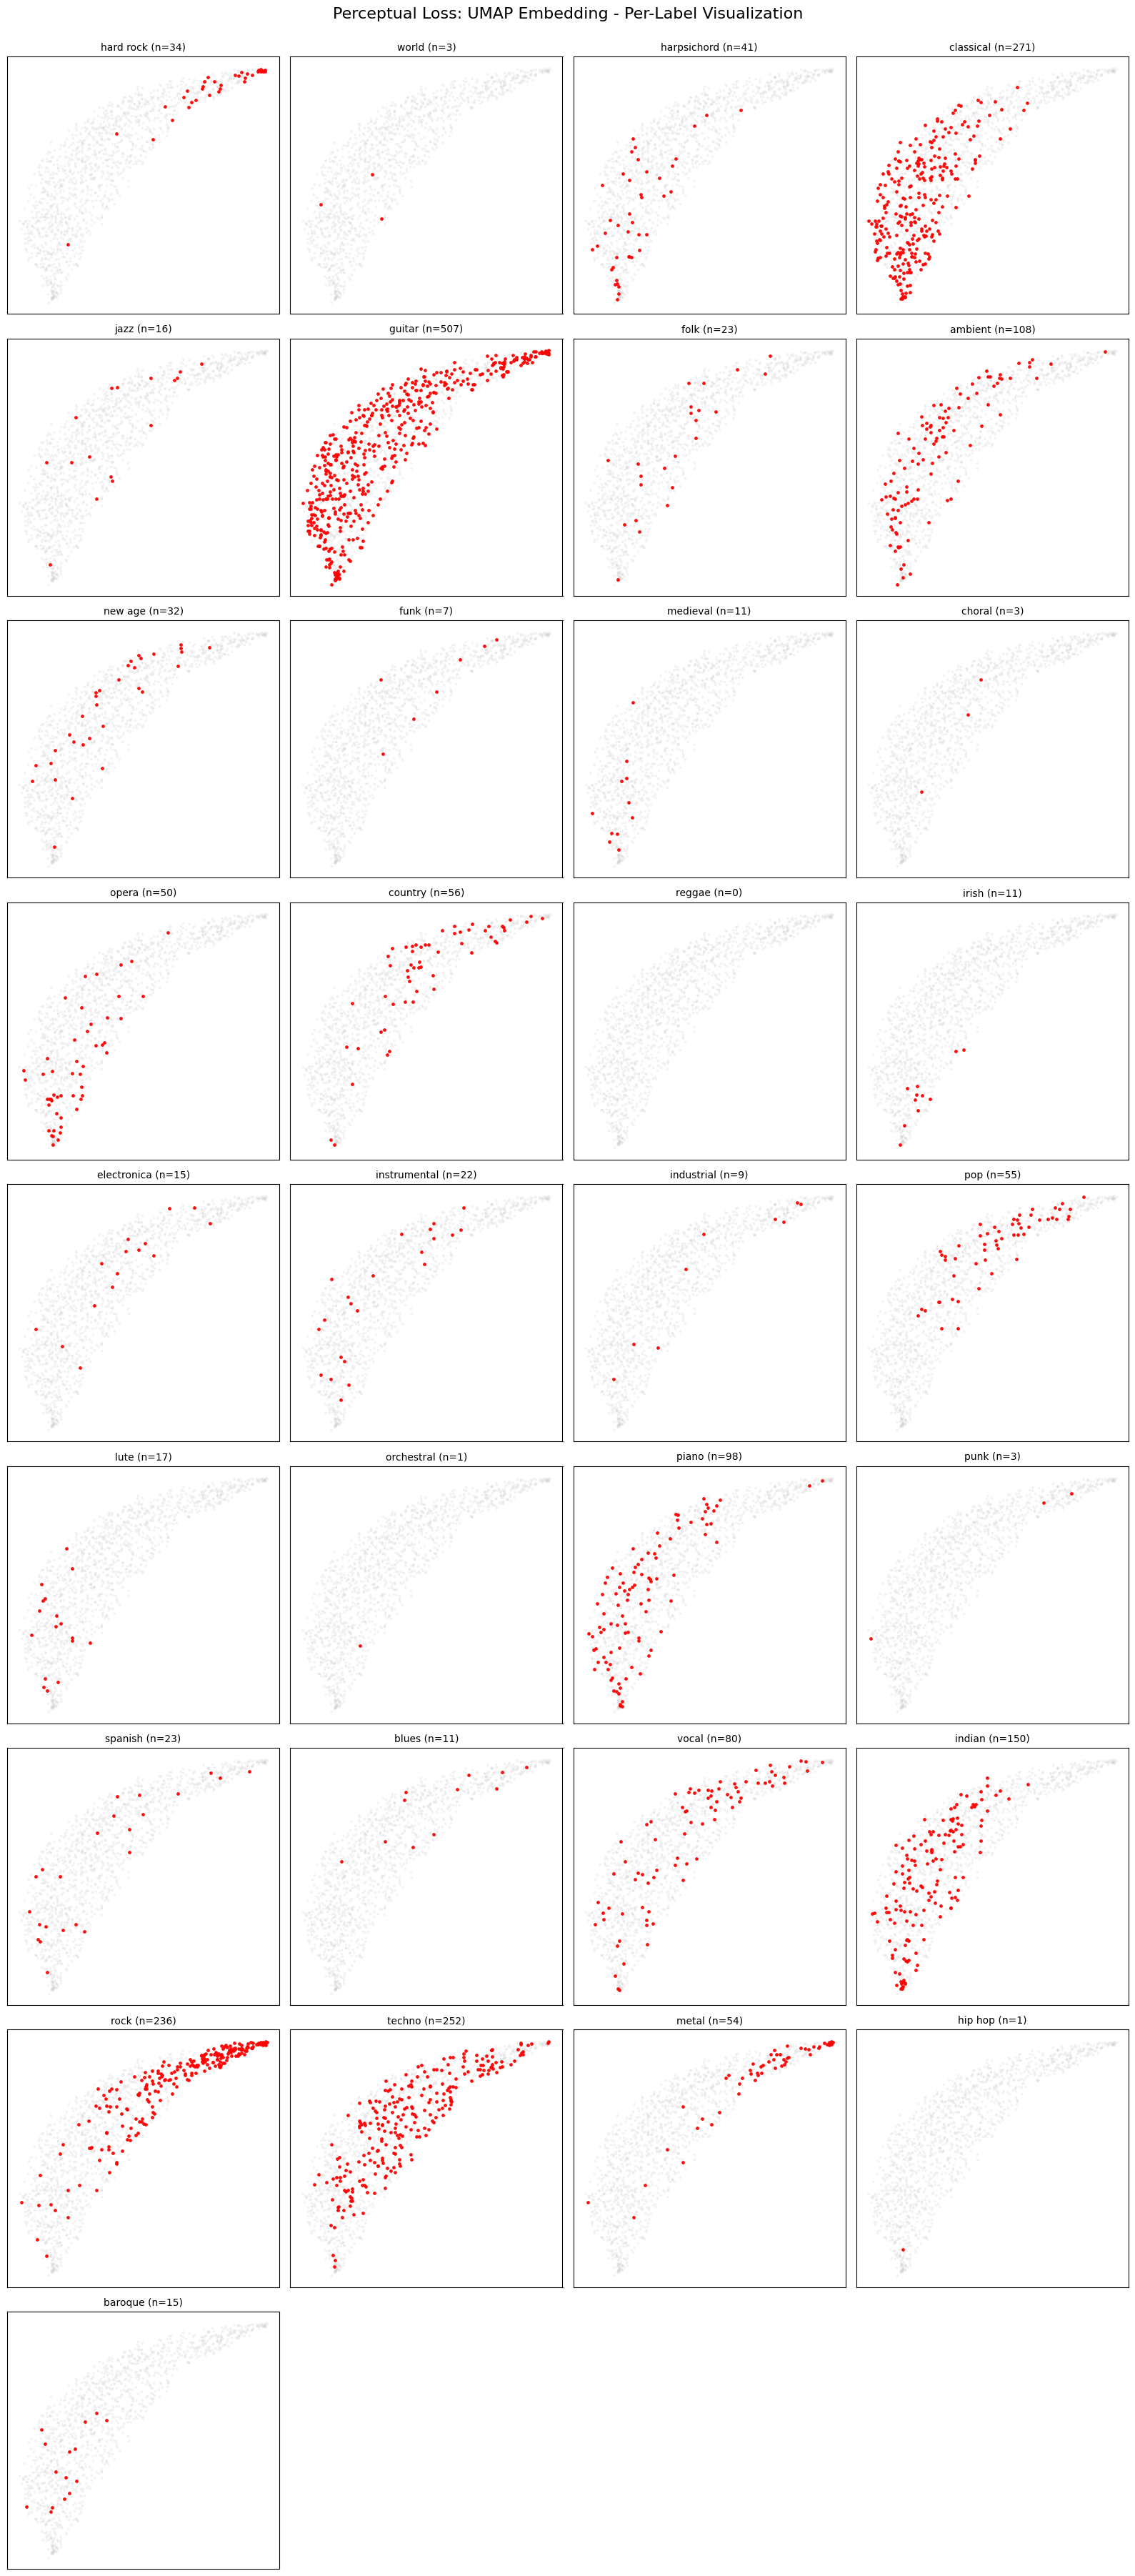

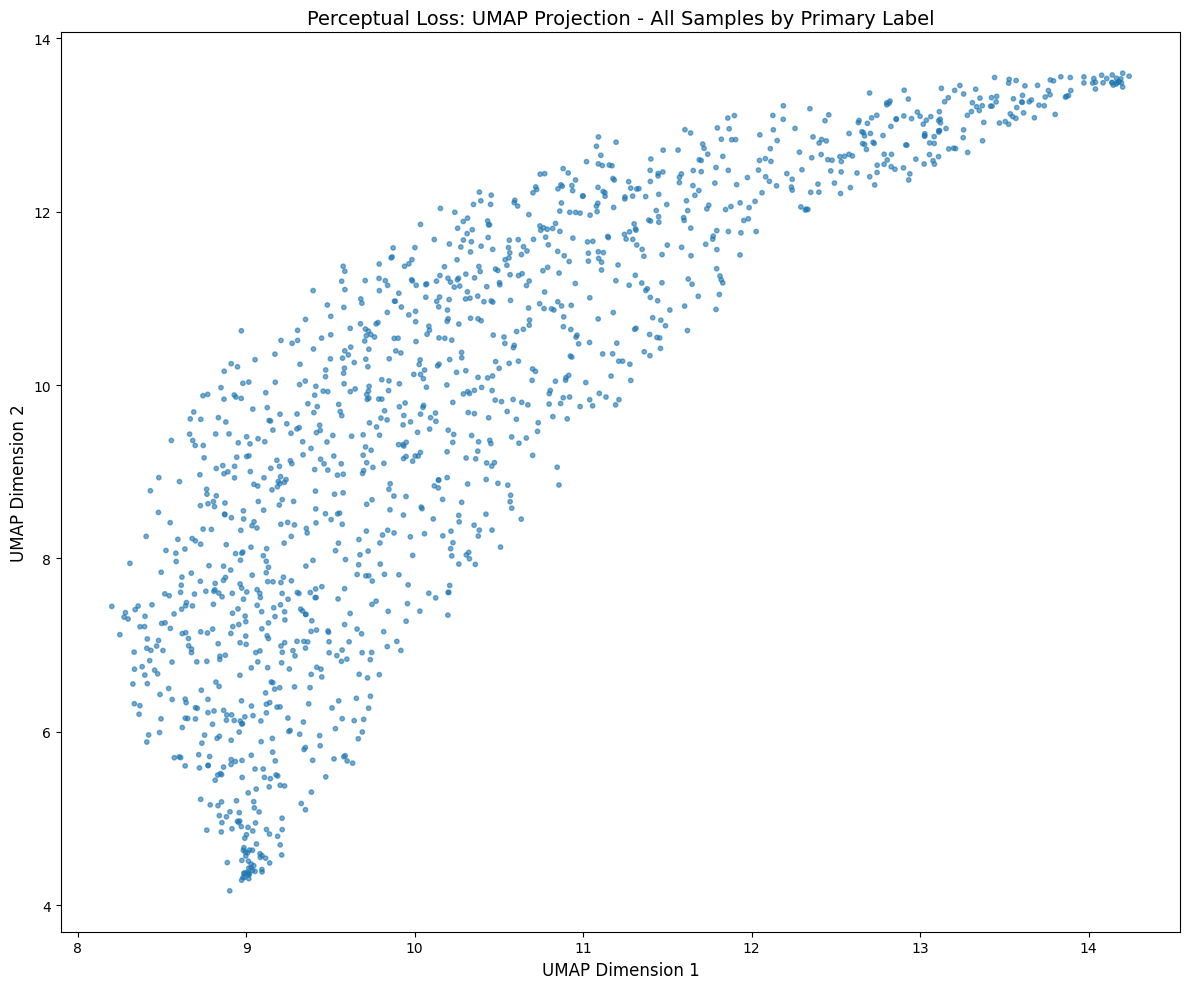

In [344]:
# ========================================
# Extract Embeddings and Labels
# ========================================

model_pl.eval()
embeddings = []
all_labels = []  # Store the binary label tensors directly

with torch.no_grad():
    for batch in tqdm(val_loader, desc="Extracting embeddings"):
        x = batch["audio"]
        x = x.to(device)
        
        # Ensure shape is always (batch, 1, samples)
        if x.dim() == 2:
            x = x.unsqueeze(1)
        elif x.dim() == 3 and x.shape[1] != 1:
            raise ValueError(f"Unexpected audio shape: {x.shape}")
        
        x = x[:, :, :target_length]
        
        _, z = model_pl(x)
        embeddings.append(z.cpu().numpy())
        
        # Store the multi-hot encoded labels directly
        batch_labels = batch["labels"]
        if isinstance(batch_labels, torch.Tensor):
            all_labels.append(batch_labels.cpu().numpy())
        else:
            all_labels.append(np.array(batch_labels))

# Concatenate all embeddings and labels
embeddings = np.concatenate(embeddings, axis=0)
Y = np.concatenate(all_labels, axis=0)  # Shape: (N, num_labels)

label_names = annotations.columns[1:-2]

print(f"Embeddings shape: {embeddings.shape}")
print(f"Binary label matrix shape: {Y.shape}")
print(f"Number of unique labels: {len(label_names)}")
print(f"Label names: {label_names[:10]}...")  # Show first 10
print(f"Example label vector (first sample): {Y[0]}")
print(f"Labels per sample (first sample): {[label_names[i] for i in np.where(Y[0] > 0)[0]]}")

# ========================================
# Perform UMAP Dimensionality Reduction
# ========================================

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=25,
    min_dist=0.1,
    metric='euclidean',
    random_state=42
)
emb_2d = reducer.fit_transform(embeddings)  # shape: (N, 2)

print(f"UMAP embeddings shape: {emb_2d.shape}")

# ========================================
# Visualize Each Label Separately
# ========================================

num_labels = len(label_names)
cols = 4
rows = int(np.ceil(num_labels / cols))

fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
axes = axes.flatten()  # flatten to 1D for easy indexing


for i, label_name in enumerate(label_names):
    ax = axes[i]
    
    # Boolean mask for samples that contain this label
    mask = Y[:, i].astype(bool)
    num_samples_with_label = mask.sum()
    
    # Plot all points faintly in background
    ax.scatter(
        emb_2d[:, 0], emb_2d[:, 1],
        c='lightgray', s=3, alpha=0.2
    )
    
    # Highlight only the samples with this label
    ax.scatter(
        emb_2d[mask, 0], emb_2d[mask, 1],
        c='red', s=6, alpha=0.9
    )
    
    ax.set_title(f"{label_name} (n={num_samples_with_label})", fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

# Hide unused axes if any
for j in range(num_labels, len(axes)):
    axes[j].axis("off")

fig.suptitle("Perceptual Loss: UMAP Embedding - Per-Label Visualization", fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

# ========================================
# Overall UMAP with All Labels
# ========================================

plt.figure(figsize=(12, 10))

# Create a color for each sample based on their primary label
primary_labels = [labels[0] if len(labels) > 0 else -1 for labels in natural_labels]
unique_primary = list(set(primary_labels))

colors = plt.cm.tab20(np.linspace(0, 1, len(unique_primary)))
color_map = {label: colors[i] for i, label in enumerate(unique_primary)}

scatter_colors = [color_map[label] for label in primary_labels]

plt.scatter(
    emb_2d[:, 0], 
    emb_2d[:, 1], 
    c=scatter_colors,
    s=10,
    alpha=0.6
)

plt.title('Perceptual Loss: UMAP Projection - All Samples by Primary Label', fontsize=14)
plt.xlabel('UMAP Dimension 1', fontsize=12)
plt.ylabel('UMAP Dimension 2', fontsize=12)
plt.tight_layout()
plt.show()

Extracting embeddings: 100%|██████████| 11/11 [00:08<00:00,  1.24it/s]
/Users/arianapereira/Documents/Masters/ClassWork/Machine_Learning/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Embeddings shape: (1337, 64)
Binary label matrix shape: (1337, 33)
Number of unique labels: 33
Label names: Index(['hard rock', 'world', 'harpsichord', 'classical', 'jazz', 'guitar',
       'folk', 'ambient', 'new age', 'funk'],
      dtype='object')...
Example label vector (first sample): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 1. 0. 0. 0.]
Labels per sample (first sample): ['techno']
UMAP embeddings shape: (1337, 2)


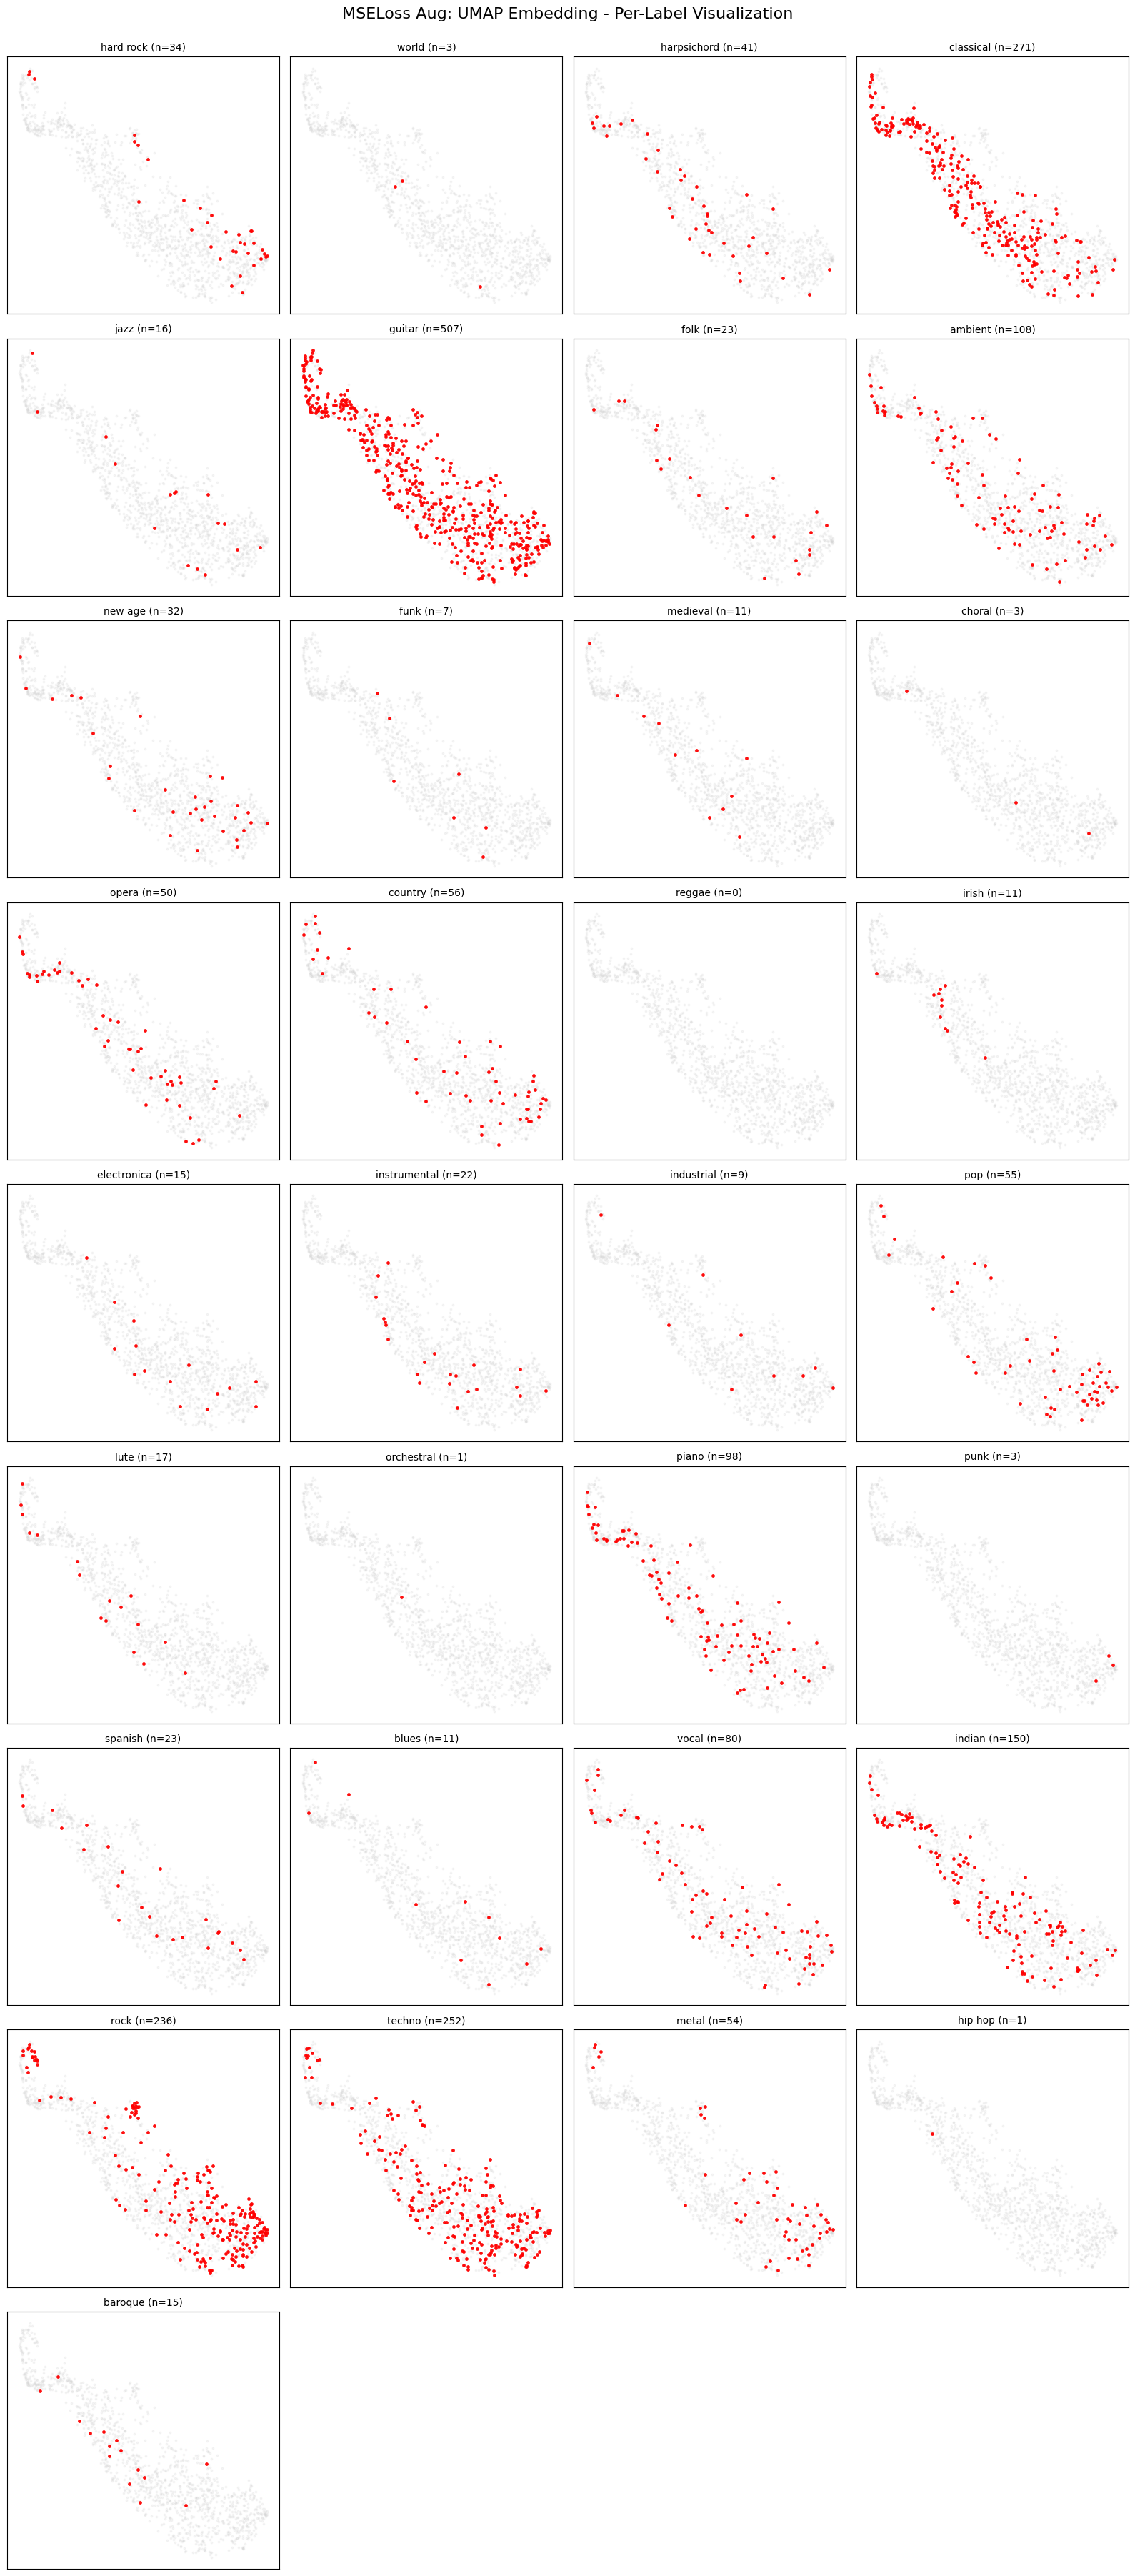

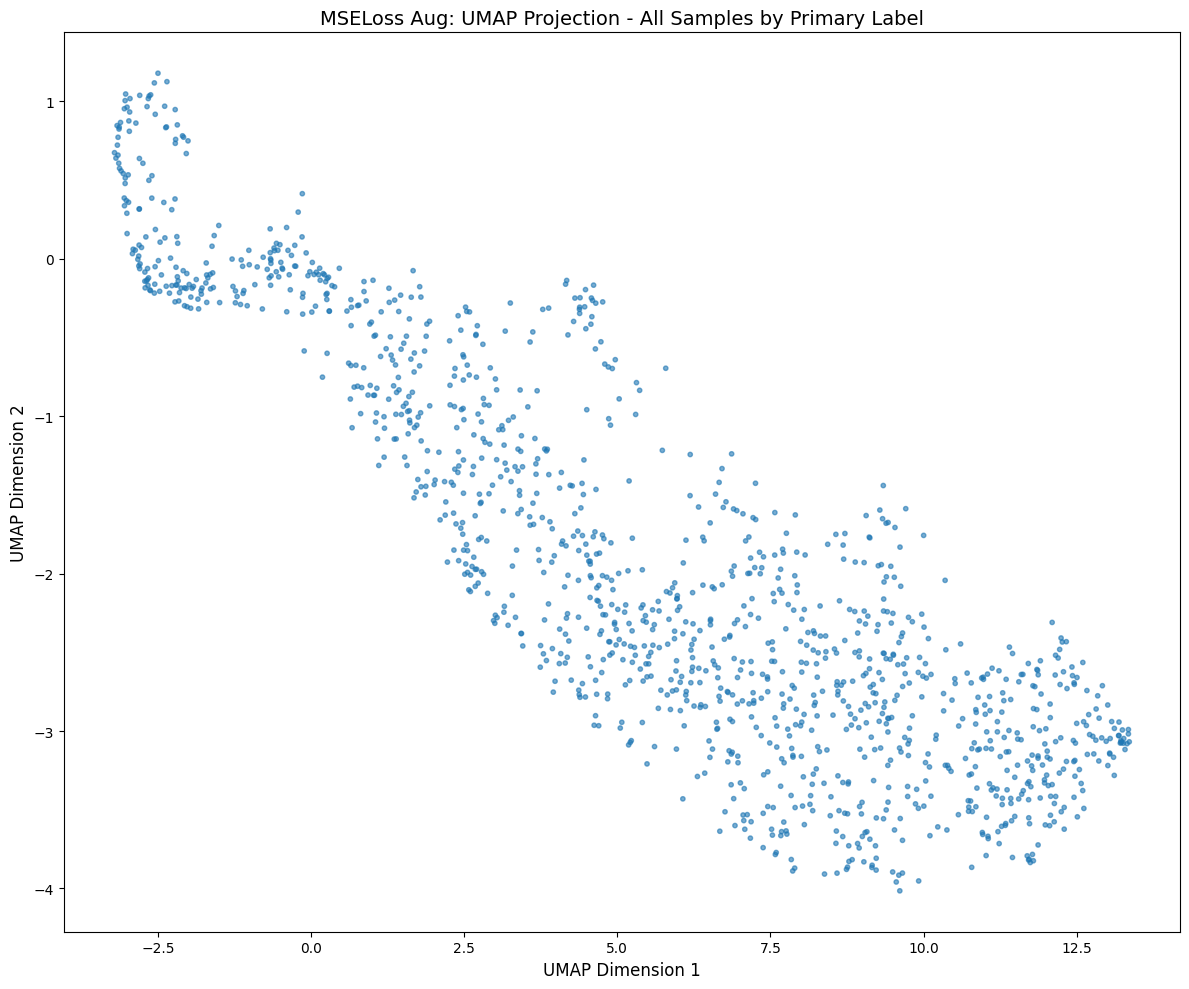

In [350]:
# ========================================
# Extract Embeddings and Labels
# ========================================

model_aug.eval()
embeddings = []
all_labels = []  # Store the binary label tensors directly

with torch.no_grad():
    for batch in tqdm(val_loader, desc="Extracting embeddings"):
        x = batch["audio"]
        x = x.to(device)
        
        # Ensure shape is always (batch, 1, samples)
        if x.dim() == 2:
            x = x.unsqueeze(1)
        elif x.dim() == 3 and x.shape[1] != 1:
            raise ValueError(f"Unexpected audio shape: {x.shape}")
        
        x = x[:, :, :target_length]
        
        _, z = model_aug(x)
        embeddings.append(z.cpu().numpy())
        
        # Store the multi-hot encoded labels directly
        batch_labels = batch["labels"]
        if isinstance(batch_labels, torch.Tensor):
            all_labels.append(batch_labels.cpu().numpy())
        else:
            all_labels.append(np.array(batch_labels))

# Concatenate all embeddings and labels
embeddings = np.concatenate(embeddings, axis=0)
Y = np.concatenate(all_labels, axis=0)  # Shape: (N, num_labels)

label_names = annotations.columns[1:-2]

print(f"Embeddings shape: {embeddings.shape}")
print(f"Binary label matrix shape: {Y.shape}")
print(f"Number of unique labels: {len(label_names)}")
print(f"Label names: {label_names[:10]}...")  # Show first 10
print(f"Example label vector (first sample): {Y[0]}")
print(f"Labels per sample (first sample): {[label_names[i] for i in np.where(Y[0] > 0)[0]]}")

# ========================================
# Perform UMAP Dimensionality Reduction
# ========================================

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=25,
    min_dist=0.1,
    metric='euclidean',
    random_state=42
)
emb_2d = reducer.fit_transform(embeddings)  # shape: (N, 2)

print(f"UMAP embeddings shape: {emb_2d.shape}")

# ========================================
# Visualize Each Label Separately
# ========================================

num_labels = len(label_names)
cols = 4
rows = int(np.ceil(num_labels / cols))

fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
axes = axes.flatten()  # flatten to 1D for easy indexing


for i, label_name in enumerate(label_names):
    ax = axes[i]
    
    # Boolean mask for samples that contain this label
    mask = Y[:, i].astype(bool)
    num_samples_with_label = mask.sum()
    
    # Plot all points faintly in background
    ax.scatter(
        emb_2d[:, 0], emb_2d[:, 1],
        c='lightgray', s=3, alpha=0.2
    )
    
    # Highlight only the samples with this label
    ax.scatter(
        emb_2d[mask, 0], emb_2d[mask, 1],
        c='red', s=6, alpha=0.9
    )
    
    ax.set_title(f"{label_name} (n={num_samples_with_label})", fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

# Hide unused axes if any
for j in range(num_labels, len(axes)):
    axes[j].axis("off")

fig.suptitle("MSELoss Aug: UMAP Embedding - Per-Label Visualization", fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

# ========================================
# Overall UMAP with All Labels
# ========================================

plt.figure(figsize=(12, 10))

# Create a color for each sample based on their primary label
primary_labels = [labels[0] if len(labels) > 0 else -1 for labels in natural_labels]
unique_primary = list(set(primary_labels))

colors = plt.cm.tab20(np.linspace(0, 1, len(unique_primary)))
color_map = {label: colors[i] for i, label in enumerate(unique_primary)}

scatter_colors = [color_map[label] for label in primary_labels]

plt.scatter(
    emb_2d[:, 0], 
    emb_2d[:, 1], 
    c=scatter_colors,
    s=10,
    alpha=0.6
)

plt.title('MSELoss Aug: UMAP Projection - All Samples by Primary Label', fontsize=14)
plt.xlabel('UMAP Dimension 1', fontsize=12)
plt.ylabel('UMAP Dimension 2', fontsize=12)
plt.tight_layout()
plt.show()